In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot



Default device set to: cuda


In [3]:
parcels = ['9-46d', '46', '9a', 'a9-46v', 'p9-46v', '9p', 'IFJa', 'IFJp', 'IFSp', 'IFSa']
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')


# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])


In [4]:

# Load data
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')

data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondRun')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

data_mdtb_s2_run = ut.recenter_fmri_data(data_mdtb_s2_run,info_mdtb_2_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')


In [5]:
# Load the GIFTI file
gifti_data = nb.load(model_name_L)
parcel_names = [label.label for label in gifti_data.labeltable.labels]
parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]

# Get the indices of the PFC parcels
ROI_cortex = []
for name in parcels:
    ROI_cortex.append(parcel_names.index(name))

ROI_mask = np.isin(glasser_atlas, ROI_cortex).astype(int)
mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)
ROI_indices = np.where(ROI_mask == 1)[0]


# S1 G matrix in DPFC

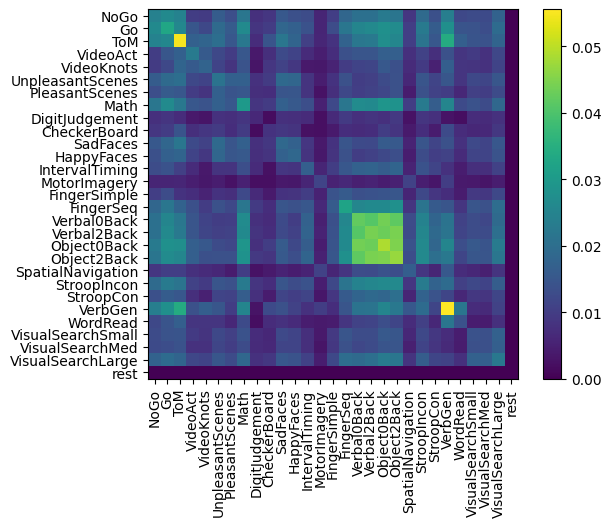

In [10]:
task_names = info_mdtb_1_run['cond_name'].unique()
n_tasks = len(task_names)
cond_vec = np.tile(np.arange(1, n_tasks + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), n_tasks)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)


plt.imshow(G_Lib, cmap='viridis')
plt.colorbar()
plt.xticks(np.arange(len(task_names)), task_names, rotation=90)
plt.yticks(np.arange(len(task_names)), task_names)
plt.show()


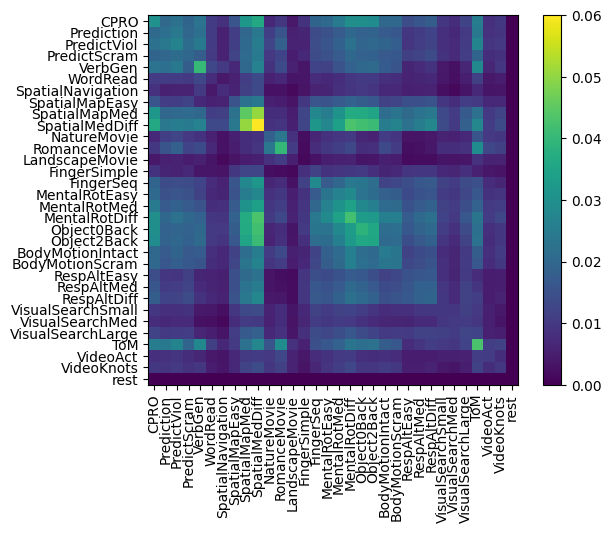

In [11]:
task_names = info_mdtb_2_run['cond_name'].unique()
n_tasks = len(task_names)
cond_vec = np.tile(np.arange(1, n_tasks + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), n_tasks)
Gs_list = []
E_list = []
for i in range(data_mdtb_s2_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s2_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)


plt.imshow(G_Lib, cmap='viridis')
plt.colorbar()
plt.xticks(np.arange(len(task_names)), task_names, rotation=90)
plt.yticks(np.arange(len(task_names)), task_names)
plt.show()
